**ECO 590 – Assignment 1**

**Name:** Shelsea Marte  
**Topic:** Sentiment-Fear Divergence: When Consumers and Markets Disagree

---

**Research Question**: When everyday consumers are optimistic but financial markets are fearful, who turns out to be right?

**Regression:** ReturnNextMonth_t = β₀ + β₁(SentVixGap_t) + ε

**Install Required Libraries**

In [32]:
# The exclamation mark (!) tells Jupyter to run this as a terminal command, not Python
# pip install downloads and installs the listed Python packages from the internet
# yfinance   → lets us download stock price data from Yahoo Finance
# fredapi    → lets us pull economic data (sentiment, VIX) from the FRED database
# pandas     → gives us the DataFrame table structure we use throughout the notebook
# numpy      → provides math functions like np.log() for computing log returns
# matplotlib → the base library for drawing all charts and plots
# seaborn    → a higher-level plotting library built on matplotlib (nicer statistical charts)
# -q         → stands for 'quiet'; suppresses the verbose install output so the cell stays clean
!pip install yfinance fredapi pandas numpy matplotlib seaborn -q

**Import Libraries**

In [24]:
# 'import ... as' loads a library and gives it a shorter nickname we use in every later line

import yfinance as yf             # 'yf' is the nickname; yf.download() fetches stock prices from Yahoo Finance
import pandas as pd               # 'pd' is the nickname; pd.DataFrame is the table object used everywhere
import numpy as np                # 'np' is the nickname; np.log() computes the natural log for log returns
import matplotlib.pyplot as plt   # 'plt' is the nickname; plt.plot(), plt.bar() etc draw the charts
import matplotlib.dates as mdates # 'mdates' formats the date labels on the x-axis of time-series plots
import seaborn as sns             # 'sns' is the nickname; sns.jointplot() makes the regression scatter plot
from fredapi import Fred          # imports only the Fred class from the fredapi package (not the whole package)

**Download SPY Daily Price Data (Yahoo Finance API)**

In [25]:
# yf.download() sends a GET request to Yahoo Finance's API and returns a pandas DataFrame
# 'SPY' is the ticker symbol for the S&P 500 ETF — the most widely used proxy for the US stock market
# start / end define the date range we want: 15 years of daily data (2010 through 2025)
# auto_adjust=True means Yahoo adjusts the Close price for dividends and stock splits automatically
#   (without this, a dividend payment would show as a fake price drop in the data)
# progress=False silences the download progress bar so the cell output stays clean
spy_raw = yf.download('SPY', start='2010-01-01', end='2025-12-31',
                      auto_adjust=True, progress=False)

# yfinance sometimes returns a MultiIndex column — a two-level header like ('Close', 'SPY')
# instead of the simple single-level name 'Close'
# isinstance() checks whether the columns are a MultiIndex object
# if they are, get_level_values(0) strips the second level, leaving simple column names
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)

# .rename() renames columns to lowercase for consistency throughout the notebook
# 'Close' is renamed to 'adj_close' to make explicit that the price is already dividend-adjusted
#   (because we set auto_adjust=True above)
spy = spy_raw.rename(columns={
    'Open': 'open',           # the price at market open each day
    'High': 'high',           # the highest price reached during the day
    'Low': 'low',             # the lowest price reached during the day
    'Close': 'adj_close',     # the closing price, already adjusted for dividends/splits
    'Volume': 'volume'        # number of shares traded that day
})

# the DataFrame's row index is currently unnamed; give it the label 'date' for clarity
spy.index.name = 'date'

# f-string: spy.shape[0] = number of rows (trading days)
# spy.index.min().date() = earliest date in the data
# spy.index.max().date() = latest date in the data
# this print confirms how many rows we downloaded and that the date range is correct
print(f'SPY: {spy.shape[0]} trading days, {spy.index.min().date()} to {spy.index.max().date()}')

SPY: 4023 trading days, 2010-01-04 to 2025-12-30


**Preview the SPY DataFrame**

In [27]:
# .head() displays the first 5 rows of the DataFrame in a formatted table
# this is a quick sanity check: it lets us confirm the columns exist,
# the dates look right, and the numbers are reasonable before doing any calculations
spy.head()

Price,adj_close,high,low,open,volume
date,,,,,
2010-01-04,84.796387,84.841278,83.434617,84.078091,118944600
2010-01-05,85.020851,85.058265,84.437236,84.744011,111579900
2010-01-06,85.080681,85.290183,84.871179,84.938516,116074400
2010-01-07,85.439835,85.544586,84.684126,84.923557,131091100
2010-01-08,85.724182,85.761596,85.043300,85.215389,126402800


**Compute Daily Log Returns (Derived Variable)**

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [5]:
# spy['adj_close'].shift(1) shifts the adj_close column DOWN by one row
# this means: on the row for March 5, shift(1) gives you the March 4 closing price
# dividing today's price by yesterday's price gives the gross return (e.g. 1.012 = up 1.2%)
# np.log() applies the natural logarithm, converting the gross return into a log return
# log returns are used instead of simple returns because:
#   1. they are time-additive: you can simply sum daily log returns to get a multi-day return
#   2. they are approximately normally distributed, which OLS regression assumes
spy['log_return'] = np.log(spy['adj_close'] / spy['adj_close'].shift(1))

# the very first row of the data has no 'yesterday', so shift(1) returns NaN there
# dropna() removes any row where log_return is NaN
# subset=['log_return'] means: only drop rows where THAT column is NaN (not other columns)
# inplace=True modifies spy directly instead of returning a new DataFrame
spy.dropna(subset=['log_return'], inplace=True)

# confirms the column was created successfully
print('log returns computed')

# .describe() computes summary statistics: count, mean, std, min, 25th percentile, median, 75th, max
# .round(6) rounds each number to 6 decimal places (log returns are very small numbers)
# this lets us verify the returns look realistic (daily SPY returns are typically between -0.05 and +0.05)
spy['log_return'].describe().round(6)

log returns computed


count    4022.000000
mean        0.000519
std         0.010864
min        -0.115886
25%        -0.003712
50%         0.000706
75%         0.005773
max         0.099863
Name: log_return, dtype: float64

**Connect to the FRED API**

In [6]:
# FRED_KEY is a personal API key that authenticates our requests to the FRED database
# they require this key so they can identify who is making requests
# every user gets their own free key at fred.stlouisfed.org/docs/api/api_key.html
FRED_KEY = '98fc94cd92def0289b66f355d0a47d9d'

# Fred() creates an authenticated connection object using our key
# once this object is created, every call to fred.get_series() automatically
# includes our API key in the request URL — we never have to pass it manually again
fred = Fred(api_key=FRED_KEY)

**Download Consumer Sentiment from FRED (UMCSENT)**

In [7]:
# fred.get_series() sends a GET request to the FRED API and returns a pandas Series
# 'UMCSENT' is the FRED series ID for the University of Michigan Consumer Sentiment Index
#   this is a monthly survey measuring how confident US households feel about the economy
#   the index ranges from roughly 50 (very pessimistic) to 110 (very optimistic)
# observation_start / observation_end limit the date range to match our SPY data
sentiment_raw = fred.get_series('UMCSENT',
                                observation_start='2010-01-01',
                                observation_end='2025-12-31')

# .to_frame() converts the pandas Series into a DataFrame (a table)
# name='umich_sentiment' gives the single column a descriptive name
sentiment = sentiment_raw.to_frame(name='umich_sentiment')

# pd.to_datetime() converts the index (which may be string dates) into proper datetime objects
# this is required for resample(), merge(), and date-based operations later
sentiment.index = pd.to_datetime(sentiment.index)

# label the index 'date' to match the SPY DataFrame's index name
sentiment.index.name = 'date'

# remove any rows where the sentiment value is missing (NaN)
# inplace=True modifies the DataFrame in place
sentiment.dropna(inplace=True)

# len() counts the number of rows; confirms we got the expected number of monthly readings
print(f'Sentiment: {len(sentiment)} monthly observations')

Sentiment: 192 monthly observations


**Download VIX from FRED (VIXCLS)**

In [8]:
# 'VIXCLS' is the FRED series ID for the CBOE Volatility Index (VIX)
# the VIX measures how much volatility options traders are pricing into the S&P 500
# a high VIX (e.g. 40+) means markets are fearful; a low VIX (e.g. 12) means markets are calm
# unlike sentiment (monthly), the VIX is published DAILY — we handle the mismatch later
vix_raw = fred.get_series('VIXCLS',
                          observation_start='2010-01-01',
                          observation_end='2025-12-31')

# same cleaning steps as sentiment above:
# to_frame() → convert Series to DataFrame with a named column
vix = vix_raw.to_frame(name='vix')

# to_datetime() → make the index proper datetime objects so date math works
vix.index = pd.to_datetime(vix.index)

# label the index 'date' for consistency with the other DataFrames
vix.index.name = 'date'

# remove rows where VIX is missing (FRED occasionally has gaps on holidays)
vix.dropna(inplace=True)

# confirms we got ~4000 daily observations (about 250 trading days per year × 16 years)
print(f'VIX: {len(vix)} daily observations')

VIX: 4051 daily observations


**Plot Sentiment and VIX Together (Side-by-Side Subplots)**

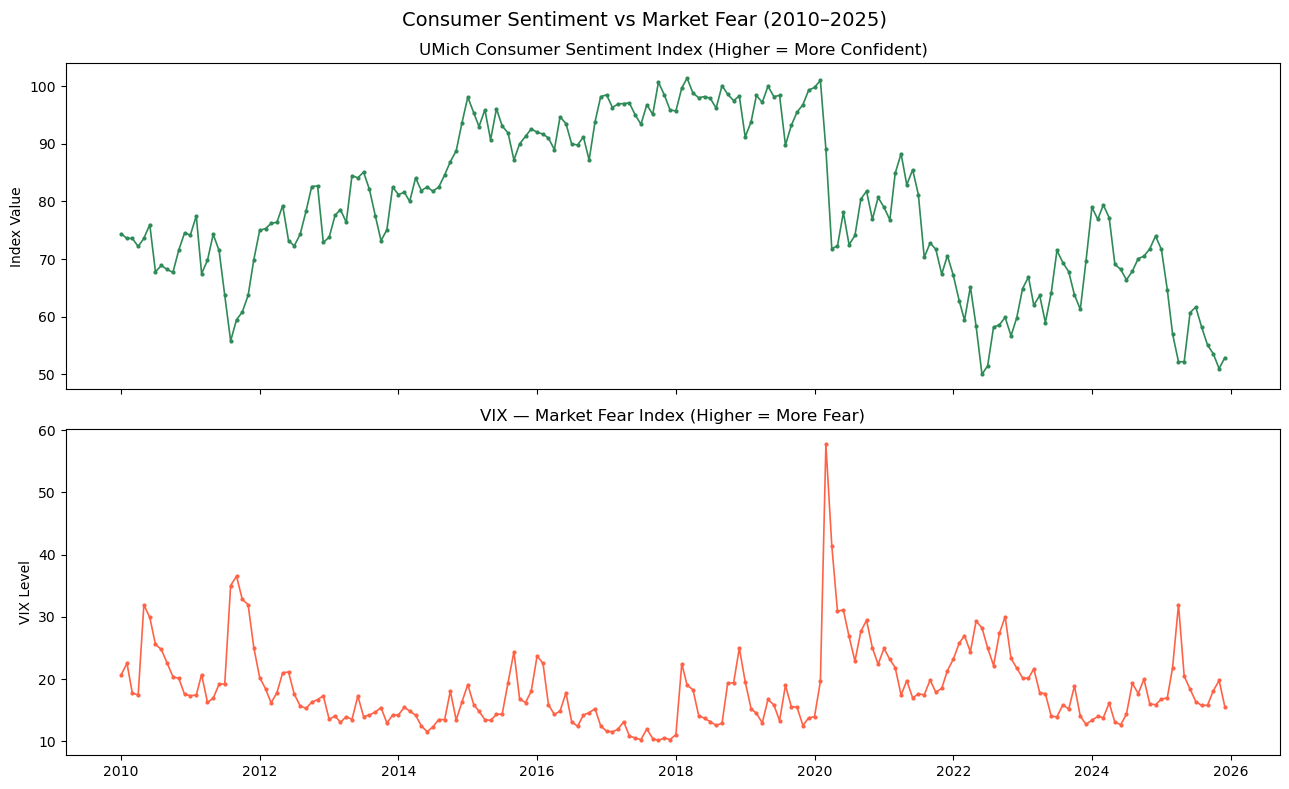

figure saved: sentiment_and_vix.png


In [9]:
# before plotting, resample VIX to monthly averages so it matches the sentiment frequency
# resample('MS') groups data by 'Month Start' (the first day of each month)
# .mean() computes the average VIX for every day within each month
# this creates one data point per month, matching the sentiment series
vix_monthly = vix.resample('MS').mean()

# plt.subplots() creates a figure canvas with 2 rows and 1 column of subplots
# figsize=(13, 8) sets the overall figure width to 13 inches, height to 8 inches
# sharex=True links the x-axes of both subplots — zooming one zooms both
# fig is the overall figure object; ax is a placeholder (we reassign ax1/ax2 below)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(13, 8), sharex=True)

# plt.subplot(2, 1, 1) selects the FIRST subplot in a 2-row, 1-column grid
# ax1 is now the axes object for the top panel
ax1 = plt.subplot(2, 1, 1)

# ax1.plot() draws a line chart of consumer sentiment over time
# sentiment.index = the date axis (x)
# sentiment['umich_sentiment'] = the sentiment values (y)
# color='seagreen' makes the line green (visually associated with positivity/confidence)
# linewidth=1.2 makes the line slightly thicker than the default
# marker='o' places a small circle at each data point; markersize=2 keeps them tiny
ax1.plot(sentiment.index, sentiment['umich_sentiment'], color='seagreen', linewidth=1.2,
         marker='o', markersize=2)

# set_title() adds a descriptive title above this subplot
ax1.set_title('UMich Consumer Sentiment Index (Higher = More Confident)')

# set_ylabel() labels the vertical axis
ax1.set_ylabel('Index Value')

# plt.subplot(2, 1, 2) selects the SECOND subplot (the bottom panel)
ax2 = plt.subplot(2, 1, 2)

# draw a line chart of the monthly VIX — same structure as the sentiment chart above
# color='tomato' makes it red (visually associated with danger/fear)
ax2.plot(vix_monthly.index, vix_monthly['vix'], color='tomato', linewidth=1.2,
         marker='o', markersize=2)
ax2.set_title('VIX — Market Fear Index (Higher = More Fear)')
ax2.set_ylabel('VIX Level')

# DateFormatter('%Y') tells matplotlib to display only the 4-digit year on the x-axis
# without this, it would show full date strings like '2015-01-01' which overcrowds the axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# YearLocator(2) places a tick mark every 2 years on the x-axis (e.g. 2010, 2012, 2014...)
# this prevents the axis from being too crowded with too many tick marks
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

# fig.suptitle() adds a single title above BOTH subplots (super-title)
# fontsize=14 makes it slightly larger than the individual subplot titles
fig.suptitle('Consumer Sentiment vs Market Fear (2010–2025)', fontsize=14)

# tight_layout() automatically adjusts spacing between subplots to prevent overlap
fig.tight_layout()

# savefig() exports the chart as a PNG image file to the current working directory
# dpi=150 sets resolution (dots per inch); higher = sharper image
# bbox_inches='tight' crops any extra white space around the figure
plt.savefig('sentiment_and_vix.png', dpi=150, bbox_inches='tight')

# plt.show() renders and displays the figure in the notebook output
plt.show()
print('figure saved: sentiment_and_vix.png')

**Construct the New Variable: `sent_vix_gap`**

**Formula:** SentVixGap = z(Sentiment) - (-1 × z(VIX))

Both series are z-scored first so they are on the same scale. VIX is inverted because high VIX (fear) is the *opposite* of high sentiment (confidence).

In [10]:
# resample('MS') groups each series by month and .mean() averages all values in that month
# this puts BOTH series on the same monthly frequency before we compare them
# sent_monthly: one row per month, showing the average consumer sentiment for that month
# vix_monthly:  one row per month, showing the average VIX level for that month
sent_monthly = sentiment.resample('MS').mean()
vix_monthly  = vix.resample('MS').mean()

# Z-SCORE NORMALIZATION for sentiment
# Problem: sentiment ranges ~50–110 and VIX ranges ~10–80 — totally different scales
# Solution: convert each to a z-score so '1 unit' means the same thing in both series
# z = (x - mean) / standard_deviation
# subtracting the mean centers the series at 0
# dividing by std scales it so 1 unit = 1 standard deviation above/below the historical average
sent_monthly['sent_z'] = (
    (sent_monthly['umich_sentiment'] - sent_monthly['umich_sentiment'].mean())
    / sent_monthly['umich_sentiment'].std()
)

# Z-SCORE NORMALIZATION for VIX — same formula applied to the VIX column
vix_monthly['vix_z'] = (
    (vix_monthly['vix'] - vix_monthly['vix'].mean())
    / vix_monthly['vix'].std()
)

# .join() merges two DataFrames side-by-side on their shared index (the date)
# how='inner' keeps only months that exist in BOTH DataFrames (drops any month missing from either)
# result: one DataFrame with columns: umich_sentiment, sent_z, vix, vix_z
monthly = sent_monthly.join(vix_monthly, how='inner')

# CREATE THE NEW VARIABLE: sent_vix_gap
# Key insight: a high VIX means fear (bad), but a high sentiment means confidence (good)
# they point in OPPOSITE directions, so we must invert VIX before comparing
# multiplying vix_z by -1 flips it: high fear becomes a very NEGATIVE number
# the formula is: gap = sent_z - (-vix_z) = sent_z + vix_z
# large POSITIVE gap → consumers are unusually more optimistic than markets are fearful
# near ZERO          → consumers and markets largely agree
# large NEGATIVE gap → markets are unusually calmer than consumers are pessimistic
monthly['sent_vix_gap'] = monthly['sent_z'] - (-1 * monthly['vix_z'])

# remove any rows where any column is NaN (safety check after the join and calculations)
monthly.dropna(inplace=True)

# .describe() shows count, mean, std, min, percentiles, max of the new variable
# .round(2) keeps the output readable by rounding to 2 decimal places
# expected: mean ≈ 0 (because we z-scored), std ≈ 1
print('Sentiment-VIX Gap summary:')
print(monthly['sent_vix_gap'].describe().round(2))

Sentiment-VIX Gap summary:
count    192.00
mean      -0.00
std        1.09
min       -2.37
25%       -0.73
50%       -0.06
75%        0.56
max        6.96
Name: sent_vix_gap, dtype: float64


**Preview the Monthly DataFrame**

In [11]:
# .head() shows the first 5 rows of the monthly DataFrame in a formatted table
# lets us verify the new sent_vix_gap column was created correctly
# and that all 4 columns (umich_sentiment, sent_z, vix, vix_z, sent_vix_gap) are present
monthly.head()

,umich_sentiment,sent_z,vix,vix_z,sent_vix_gap
date,,,,,
2010-01-01,74.4,-0.355675,20.643158,0.356673,0.000998
2010-02-01,73.6,-0.413912,22.540000,0.657919,0.244007
2010-03-01,73.6,-0.413912,17.767391,-0.100040,-0.513952
2010-04-01,72.2,-0.515826,17.424286,-0.154530,-0.670356
2010-05-01,73.6,-0.413912,31.929500,2.149107,1.735195


**Bar Chart: Visualize the Sentiment-VIX Gap Over Time**

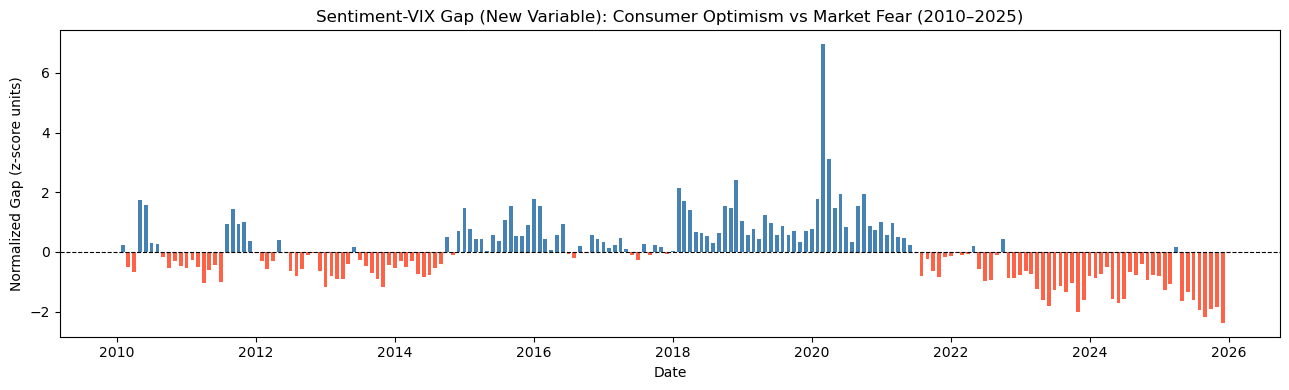

figure saved: sent_vix_gap.png


In [12]:
# plt.figure() creates a new figure (blank canvas)
# figsize=(13, 4) makes it wide but short — appropriate for a time-series bar chart
fig = plt.figure(figsize=(13, 4))

# list comprehension: creates a list of color strings, one per month in the dataset
# for each value x in sent_vix_gap:
#   if x >= 0 (consumers more optimistic than markets): assign 'steelblue' (blue)
#   if x < 0  (markets calmer than consumers expect):   assign 'tomato' (red)
# this encodes the sign of the gap as color directly on the chart
colors = ['steelblue' if x >= 0 else 'tomato' for x in monthly['sent_vix_gap']]

# plt.bar() draws a bar chart
# monthly.index = the dates (x-axis)
# monthly['sent_vix_gap'] = the height of each bar (y-axis)
# color=colors applies our per-bar color list from above
# width=20 means each bar is 20 days wide (the x-axis is in days, so this fills each month)
plt.bar(monthly.index, monthly['sent_vix_gap'], color=colors, width=20)

# axhline() draws a horizontal line across the entire chart at y=0
# this is the visual dividing line between positive (blue) and negative (red) bars
# color='black', linewidth=0.8 = thin black line; linestyle='--' = dashed
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# add a descriptive title, y-axis label, and x-axis label
plt.title('Sentiment-VIX Gap (New Variable): Consumer Optimism vs Market Fear (2010–2025)')
plt.ylabel('Normalized Gap (z-score units)')  # units are z-scores (standard deviations)
plt.xlabel('Date')

# tight_layout() removes excess whitespace so the chart uses the full figure area
plt.tight_layout()

# save the chart to a PNG file at 150 dpi (good print quality)
# bbox_inches='tight' trims extra whitespace around the figure when saving
plt.savefig('sent_vix_gap.png', dpi=150, bbox_inches='tight')

# render the chart in the notebook output
plt.show()
print('figure saved: sent_vix_gap.png')

**Merge Daily SPY Data with Monthly Sentiment/VIX Data**

In [13]:
# PROBLEM: spy is DAILY (one row per trading day) but monthly has one row per MONTH
# SOLUTION: create a 'year_month' key column in both DataFrames, then merge on that key
# this assigns each daily SPY row the monthly sentiment/VIX reading for that month

# reset_index() moves the 'date' index into a regular column
# this is required because merge() works on columns, not the index
spy_m     = spy.reset_index()      # now spy_m has a regular 'date' column
monthly_m = monthly.reset_index()  # now monthly_m has a regular 'date' column

# dt.to_period('M') collapses a full date like 2020-03-15 to just the period '2020-03'
# every day in March 2020 becomes the same period value '2020-03'
# this creates the shared key we use to match daily rows to monthly rows
spy_m['year_month']     = spy_m['date'].dt.to_period('M')
monthly_m['year_month'] = monthly_m['date'].dt.to_period('M')

# keep only the columns we actually need from the monthly side
# 'year_month' is the merge key; the other three are the variables we want to attach
monthly_m = monthly_m[['year_month', 'umich_sentiment', 'vix', 'sent_vix_gap']]

# .merge() is like a SQL JOIN — it combines two DataFrames based on a shared key column
# on='year_month' means: match rows where both DataFrames have the same month period
# how='left' means: keep ALL rows from spy_m (the left table)
#   and attach matching monthly data where available; NaN if no match
merged = spy_m.merge(monthly_m, on='year_month', how='left')

# drop the 'year_month' helper column — it was only needed for the merge
# inplace=True modifies merged directly
merged.drop(columns=['year_month'], inplace=True)

# remove any rows where ANY column is NaN (e.g. edges of the date range)
merged.dropna(inplace=True)

# put the 'date' column back as the index (it's more natural for time-series DataFrames)
merged.set_index('date', inplace=True)

# ensure the index is in datetime format (required for resample, plot, etc.)
merged.index = pd.to_datetime(merged.index)

# confirm the merge worked: shape tells us (number of rows, number of columns)
# expected: ~4023 rows (one per trading day) and 8 columns
print(f'Merged dataset shape: {merged.shape}')
print(f'Date range: {merged.index.min().date()} to {merged.index.max().date()}')

Merged dataset shape: (4022, 9)
Date range: 2010-01-05 to 2025-12-30


**Preview the Merged DataFrame**

In [14]:
# .head() shows the first 5 rows of the merged daily DataFrame
# we can verify that each trading day now has the correct monthly sentiment and vix values
# e.g. all rows in January 2010 should show the same umich_sentiment reading
merged.head()

,adj_close,high,low,open,volume,log_return,umich_sentiment,vix,sent_vix_gap
date,,,,,,,,,
2010-01-05,85.020851,85.058265,84.437236,84.744011,111579900,0.002644,74.4,20.643158,0.000998
2010-01-06,85.080681,85.290183,84.871179,84.938516,116074400,0.000703,74.4,20.643158,0.000998
2010-01-07,85.439835,85.544586,84.684126,84.923557,131091100,0.004212,74.4,20.643158,0.000998
2010-01-08,85.724182,85.761596,85.043300,85.215389,126402800,0.003323,74.4,20.643158,0.000998
2010-01-11,85.843880,86.143165,85.477245,86.105757,106375700,0.001395,74.4,20.643158,0.000998


**Check for and Remove Duplicate Dates**

In [15]:
# .index.duplicated() returns a boolean array: True where the date appears more than once
# .sum() counts how many True values there are (i.e. how many duplicate rows exist)
n_dupes = merged.index.duplicated().sum()
print(f'Duplicate dates: {n_dupes}')  # expect 0; if > 0, the merge created unintended duplicates

# ~ is the boolean NOT operator: it flips True to False and False to True
# so ~merged.index.duplicated() = True for UNIQUE rows, False for DUPLICATES
# keep='first' marks the SECOND (and later) occurrence as the duplicate, keeping the first
# this line removes all duplicate rows, keeping only the first occurrence of each date
merged = merged[~merged.index.duplicated(keep='first')]

Duplicate dates: 0


**Rename Columns, Select Finals, Enforce Data Types**

In [16]:
# .rename() gives every column a clear, descriptive name with a consistent 'spy_' prefix
# this makes it obvious which columns come from the stock data vs. the economic indicators
merged = merged.rename(columns={
    'open':            'spy_open',        # SPY's opening price for that day
    'high':            'spy_high',        # SPY's highest price for that day
    'low':             'spy_low',         # SPY's lowest price for that day
    'adj_close':       'spy_adj_close',   # SPY's dividend-adjusted closing price
    'volume':          'spy_volume',      # number of SPY shares traded that day
    'log_return':      'log_return',      # daily log return (already computed)
    'umich_sentiment': 'umich_sentiment', # monthly UMich consumer sentiment reading
    'vix':             'vix',             # monthly average VIX level
    'sent_vix_gap':    'sent_vix_gap'     # our new derived variable
})

# define the exact list of columns we want in the final dataset (in display order)
final_cols = ['spy_open', 'spy_high', 'spy_low', 'spy_adj_close',
              'spy_volume', 'log_return', 'umich_sentiment', 'vix', 'sent_vix_gap']

# select only those columns from merged, dropping any extras created during processing
merged = merged[final_cols]

# pd.to_numeric() converts every column to a numeric data type
# errors='coerce' means: if a value cannot be converted (e.g. text), replace it with NaN
# .apply() runs this conversion on every column in the DataFrame
merged = merged.apply(pd.to_numeric, errors='coerce')

# drop any rows that have NaN in any column after the conversion
merged.dropna(inplace=True)

# select only the columns that have float64 (decimal) data type
float_cols = merged.select_dtypes(include='float64').columns

# round all float columns to 6 decimal places to avoid unnecessary precision noise
merged[float_cols] = merged[float_cols].round(6)

# final confirmation: shape tells us (rows, columns); isna().sum() shows missing values per column
# both should confirm a clean dataset with 0 missing values
print(f'Final dataset shape: {merged.shape}')
print('\nMissing values per column:')
print(merged.isna().sum())

Final dataset shape: (4022, 9)

Missing values per column:
spy_open           0
spy_high           0
spy_low            0
spy_adj_close      0
spy_volume         0
log_return         0
umich_sentiment    0
vix                0
sent_vix_gap       0
dtype: int64


**Summary Statistics for Key Variables**

In [17]:
# select only the 4 columns relevant to the research question
# .describe() computes count, mean, std, min, 25%, 50%, 75%, max for each
# .round(4) keeps 4 decimal places — enough precision without being overwhelming
# this table lets us check: are the values realistic? are there any obvious outliers?
merged[['log_return', 'umich_sentiment', 'vix', 'sent_vix_gap']].describe().round(4)

,log_return,umich_sentiment,vix,sent_vix_gap
count,4022.0000,4022.0000,4022.0000,4022.0000
mean,0.0005,79.2735,18.4108,0.0012
std,0.0109,13.7144,6.3239,1.0858
min,-0.1159,50.0000,10.1255,-2.3733
25%,-0.0037,69.4000,14.0726,-0.7238
50%,0.0007,78.3000,16.9568,-0.0642
75%,0.0058,92.4500,20.7235,0.5621
max,0.0999,101.4000,57.7368,6.9621


**Scatter Plots: Does the Gap Predict Returns?**

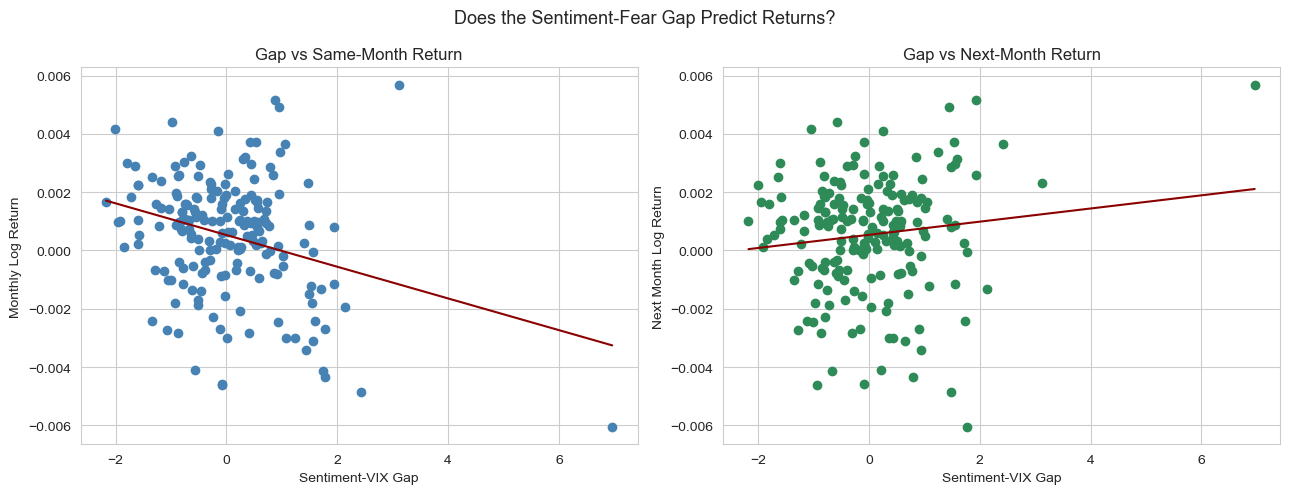

figure saved: gap_vs_returns.png


In [31]:
# resample the daily merged data to monthly averages to reduce noise in the scatter plot
# daily returns are very noisy; monthly averages reveal trends more clearly
# [['log_return', 'sent_vix_gap']] selects only the two columns we need for the scatter
# .resample('MS').mean() takes the monthly average of both columns
# .dropna() removes any months where either column is missing
plot_df = merged[['log_return', 'sent_vix_gap']].resample('MS').mean().dropna()

# shift(-1) shifts the log_return column UP by one row
# result: on the row for month t, 'return_next_month' contains month t+1's return
# this is the key transformation: we want to test whether THIS month's gap predicts NEXT month's return
plot_df['return_next_month'] = plot_df['log_return'].shift(-1)

# the last row now has NaN in return_next_month (no 'next month' exists), so drop it
plot_df.dropna(inplace=True)

# sns.set_style('whitegrid') applies a clean white background with light grid lines to all plots
sns.set_style('whitegrid')

# create a figure with 1 row and 2 columns of subplots (two scatter plots side by side)
# figsize=(13, 5) = 13 inches wide, 5 inches tall
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# ── LEFT PANEL: gap vs SAME-month return (a baseline / control comparison) ──
ax1 = plt.subplot(1, 2, 1)  # select the first subplot in a 1-row, 2-column grid

# .scatter() plots each month as a blue dot
# x = the sentiment-VIX gap; y = the log return for the SAME month
ax1.scatter(plot_df['sent_vix_gap'], plot_df['log_return'], color='steelblue')

# np.polyfit() fits a straight line (degree=1 polynomial) through the scatter points
# it returns m (slope) and b (intercept) of the best-fit line: y = m*x + b
m, b = np.polyfit(plot_df['sent_vix_gap'], plot_df['log_return'], 1)

# np.linspace() creates 100 evenly spaced x-values spanning the full range of the gap variable
# these are the x-coordinates for drawing the smooth trend line
x_line = np.linspace(plot_df['sent_vix_gap'].min(), plot_df['sent_vix_gap'].max(), 100)

# plot the trend line: for each x value, compute y = m*x + b
# color='darkred' makes the trend line stand out against the blue dots
ax1.plot(x_line, m * x_line + b, color='darkred')
ax1.set_xlabel('Sentiment-VIX Gap')    # x-axis label
ax1.set_ylabel('Monthly Log Return')   # y-axis label
ax1.set_title('Gap vs Same-Month Return')  # subplot title

# ── RIGHT PANEL: gap vs NEXT-month return (the actual research question) ──
ax2 = plt.subplot(1, 2, 2)  # select the second subplot

# same scatter, but y = return_next_month (the return ONE month into the future)
# this is the predictive scatter: does today's disagreement predict tomorrow's return?
ax2.scatter(plot_df['sent_vix_gap'], plot_df['return_next_month'], color='seagreen')

# fit and draw the trend line for the next-month return (same method as above)
m2, b2 = np.polyfit(plot_df['sent_vix_gap'], plot_df['return_next_month'], 1)
ax2.plot(x_line, m2 * x_line + b2, color='darkred')
ax2.set_xlabel('Sentiment-VIX Gap')
ax2.set_ylabel('Next Month Log Return')
ax2.set_title('Gap vs Next-Month Return')

# overall title for both panels
fig.suptitle('Does the Sentiment-Fear Gap Predict Returns?', fontsize=13)
fig.tight_layout()  # prevent overlap between subplot titles and axis labels

plt.savefig('gap_vs_returns.png', dpi=150, bbox_inches='tight')  # save to PNG
plt.show()
print('figure saved: gap_vs_returns.png')

**Save the Final Dataset to CSV**

In [30]:
# .to_csv() exports the entire merged DataFrame to a CSV file on disk
# 'final_dataset.csv' is the filename; it will be created in the current working directory
# index=True means the 'date' row index is included as the first column in the file
#   (if index=False, the dates would be lost)
merged.to_csv('final_dataset.csv', index=True)

# print a summary confirming the save was successful
# len(merged) = number of rows; merged.shape[1] = number of columns
print('Dataset saved: final_dataset.csv')
print(f'  Rows      : {len(merged):,}')   # :, formats the number with commas (e.g. 4,023)
print(f'  Columns   : {merged.shape[1]}')
print(f'  Date range: {merged.index.min().date()} to {merged.index.max().date()}')
print()

# print a data dictionary: a plain-English description of every column in the dataset
# this documents what each column is for anyone reading the CSV later
print('Column descriptions:')
descriptions = {
    'spy_open':       'SPY opening price (USD)',
    'spy_high':       'SPY daily high price (USD)',
    'spy_low':        'SPY daily low price (USD)',
    'spy_adj_close':  'SPY adjusted closing price — accounts for dividends and splits',
    'spy_volume':     'number of SPY shares traded that day',
    'log_return':     'DERIVED — daily log return: ln(P_t / P_{t-1})',
    'umich_sentiment':'UMich Consumer Sentiment Index (monthly, from FRED API)',
    'vix':            'CBOE VIX market fear index (daily, from FRED API)',
    'sent_vix_gap':   'NEW VARIABLE — normalized sentiment minus normalized VIX (disagreement measure)'
}

# loop over the dictionary items: col = column name, desc = its description
# {col:<20} left-aligns the column name in a field 20 characters wide (for tidy alignment)
for col, desc in descriptions.items():
    print(f'  {col:<20} {desc}')

Dataset saved: final_dataset.csv
  Rows      : 4,022
  Columns   : 9
  Date range: 2010-01-05 to 2025-12-30

Column descriptions:
  spy_open             SPY opening price (USD)
  spy_high             SPY daily high price (USD)
  spy_low              SPY daily low price (USD)
  spy_adj_close        SPY adjusted closing price — accounts for dividends and splits
  spy_volume           number of SPY shares traded that day
  log_return           DERIVED — daily log return: ln(P_t / P_{t-1})
  umich_sentiment      UMich Consumer Sentiment Index (monthly, from FRED API)
  vix                  CBOE VIX market fear index (daily, from FRED API)
  sent_vix_gap         NEW VARIABLE — normalized sentiment minus normalized VIX (disagreement measure)


**Preview the Final Dataset**

In [29]:
# .tail(3) shows the LAST 3 rows of the DataFrame
# used here instead of .head() to verify the most recent data (end of 2025) looks correct
merged.tail(3)

,spy_open,spy_high,spy_low,spy_adj_close,spy_volume,log_return,umich_sentiment,vix,sent_vix_gap
date,,,,,,,,,
2025-12-26,688.758989,689.776169,687.392725,688.429871,41613300,-0.000101,52.9,15.548182,-2.373266
2025-12-29,685.667409,687.322922,684.201442,685.976562,62559500,-0.003570,52.9,15.548182,-2.373266
2025-12-30,685.577720,686.684682,684.710094,685.138916,47160700,-0.001222,52.9,15.548182,-2.373266


**Final Regression Plot: Joint Scatter with Trend Line (Seaborn)**

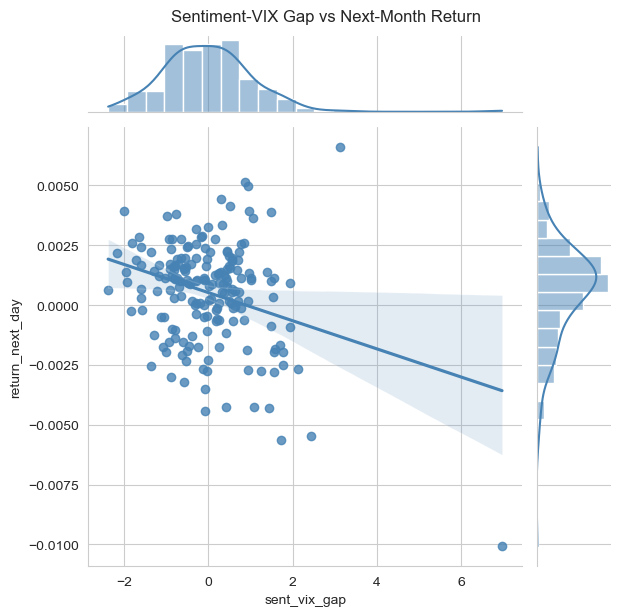

figure saved: scatter_gap_vs_return.png


In [33]:
# re-import libraries at the top of this cell for clarity (since I'm sharing my notebook)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the final dataset we saved to disk in the previous cell
df = pd.read_csv('final_dataset.csv')

# pd.to_datetime() converts the 'date' column (which is a string after loading from CSV)
# back into a proper datetime object — required for resample() and time-series operations
df['date'] = pd.to_datetime(df['date'])

# shift(-1) moves the log_return column up by one row
# result: each row's 'return_next_day' is actually tomorrow's return
# this creates the forward-looking dependent variable for the regression
df['return_next_day'] = df['log_return'].shift(-1)

# set 'date' as the DataFrame index so resample() can use it
# [['sent_vix_gap', 'return_next_day']] selects only the two columns needed
# .resample('MS').mean() collapses daily data to monthly averages (Month Start)
# .dropna() removes any months where either column is NaN (e.g. the last row after shift)
monthly = df.set_index('date')[['sent_vix_gap', 'return_next_day']].resample('MS').mean().dropna()

# sns.set_style('whitegrid') applies a clean white background with light grid lines
sns.set_style('whitegrid')

# sns.jointplot() creates a three-panel figure:
#   - center: scatter plot of sent_vix_gap (x) vs return_next_day (y)
#   - top margin: distribution of sent_vix_gap (histogram/KDE)
#   - right margin: distribution of return_next_day (histogram/KDE)
# x='sent_vix_gap' = the predictor variable (this month's gap)
# y='return_next_day' = the outcome variable (next month's return)
# kind='reg' adds an OLS regression line with a confidence band to the scatter
# color='steelblue' sets the color for dots and distributions
sns.jointplot(x='sent_vix_gap', y='return_next_day', data=monthly, kind='reg', color='steelblue')

# plt.suptitle() adds an overall title above all three panels
# y=1.02 nudges the title slightly above the top panel to avoid overlap
plt.suptitle('Sentiment-VIX Gap vs Next-Month Return', y=1.02)

# save the joint plot to a PNG file
# bbox_inches='tight' ensures the marginal panels are not cut off when saving
plt.savefig('scatter_gap_vs_return.png', dpi=150, bbox_inches='tight')

# display the chart in the notebook output
plt.show()
print('figure saved: scatter_gap_vs_return.png')